## 1. Documentation reading

- A big part of deep learning (and learning to code in general) is getting familiar with the documentation of a certain framework you're using. We'll be using the PyTorch documentation a lot throughout the rest of this course. So I'd recommend spending 10-minutes reading the following (it's okay if you don't get some things for now, the focus is not yet full understanding, it's awareness). See the documentation on torch.Tensor and for torch.cuda.

- https://docs.pytorch.org/docs/2.13/tensors.html#torch-tensor
- https://docs.pytorch.org/docs/main/notes/cuda.html#cuda-semantics 

## 2. Create a random tensor with shape (7, 7).

In [1]:
import torch
random_tensor = torch.rand(size=(7,7))
random_tensor

tensor([[0.0484, 0.0491, 0.8641, 0.3088, 0.4368, 0.8938, 0.5853],
        [0.1390, 0.4622, 0.5129, 0.6086, 0.7311, 0.0126, 0.9247],
        [0.9461, 0.6917, 0.6352, 0.3766, 0.7455, 0.3671, 0.7678],
        [0.6464, 0.1039, 0.3902, 0.9305, 0.7333, 0.2600, 0.2448],
        [0.0732, 0.7219, 0.1431, 0.3638, 0.9070, 0.1030, 0.4899],
        [0.4092, 0.2512, 0.7391, 0.3253, 0.9898, 0.7934, 0.5890],
        [0.3764, 0.9952, 0.8729, 0.3302, 0.2713, 0.2794, 0.9365]])

## 3. Perform a matrix multiplication on the tensor from 2 with another random tensor with shape (1, 7)

In [2]:
random_tensor2 = torch.rand(size=(1,7))
print(random_tensor2)

tensor([[0.7551, 0.2752, 0.9405, 0.6124, 0.4997, 0.7636, 0.6398]])


In [4]:
print(torch.matmul(random_tensor,random_tensor2)) # shapes does not match so we hae to transpose

RuntimeError: mat1 and mat2 shapes cannot be multiplied (7x7 and 1x7)

In [5]:
print(torch.matmul(random_tensor,random_tensor2.T)) 

tensor([[2.3270],
        [2.0539],
        [2.8768],
        [2.1751],
        [1.4567],
        [2.7498],
        [2.5294]])


## 4. Set the random seed to 0 and do exercises 2 & 3 over again.

In [6]:
torch.manual_seed(0)
random_tenosr = torch.rand(size=(7,7))
print(random_tensor)

random_tensor2 = torch.rand(size=(1,7))
print(random_tensor2)

result = torch.matmul(random_tensor,random_tensor2.T)

print(result)

tensor([[0.0484, 0.0491, 0.8641, 0.3088, 0.4368, 0.8938, 0.5853],
        [0.1390, 0.4622, 0.5129, 0.6086, 0.7311, 0.0126, 0.9247],
        [0.9461, 0.6917, 0.6352, 0.3766, 0.7455, 0.3671, 0.7678],
        [0.6464, 0.1039, 0.3902, 0.9305, 0.7333, 0.2600, 0.2448],
        [0.0732, 0.7219, 0.1431, 0.3638, 0.9070, 0.1030, 0.4899],
        [0.4092, 0.2512, 0.7391, 0.3253, 0.9898, 0.7934, 0.5890],
        [0.3764, 0.9952, 0.8729, 0.3302, 0.2713, 0.2794, 0.9365]])
tensor([[0.4820, 0.8198, 0.9971, 0.6984, 0.5675, 0.8352, 0.2056]])
tensor([[2.2555],
        [1.9979],
        [2.8069],
        [2.1193],
        [1.7254],
        [2.7128],
        [2.6781]])


## 5. GPU equivalent of random seeds

In [7]:
# set cpu random seed
torch.manual_seed(1234)

# set gpu random seed (if cuda is available)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1234)
    #or
    torch.cuda.manual_seed_all(1234)
print("cpu seed set to 1234")
if torch.cuda.is_available():
    print("GPU seed set to 1234")
else:
    print("Cuda is not available")

cpu seed set to 1234
Cuda is not available


## 6. Create two random tensors of shape (2, 3) and send them both to the GPU  Set torch.manual_seed(1234) when creating the tensors.

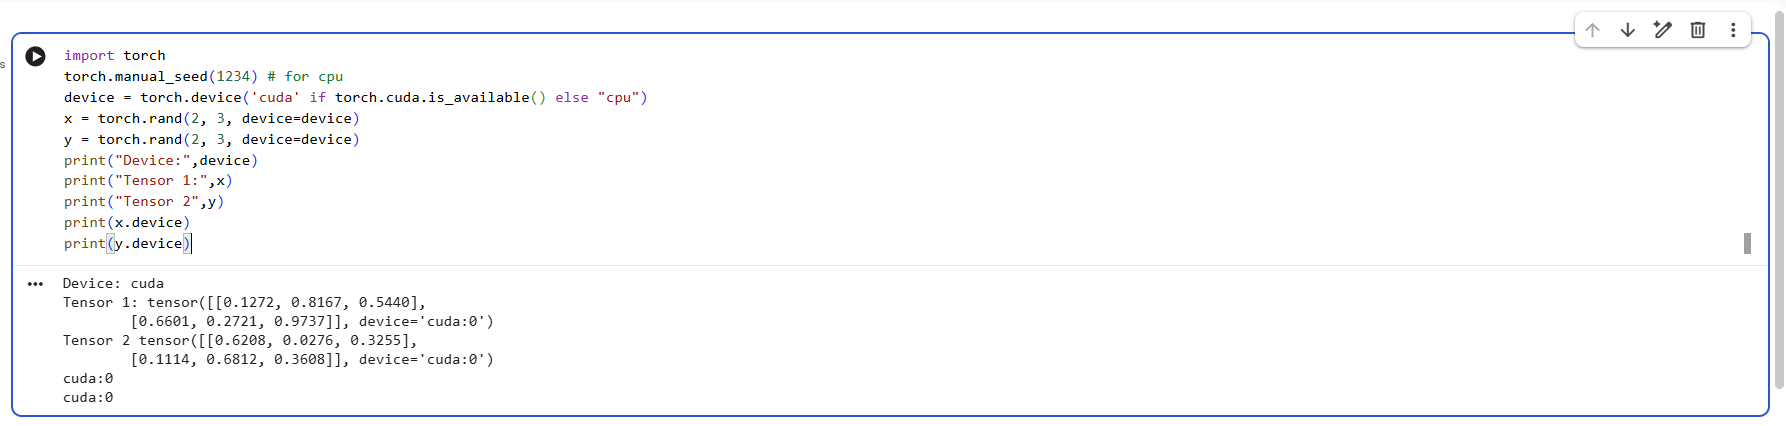

## 7. Perform a matrix multiplication on the tensors you created in 6 (again, you may have to adjust the shapes of one of the tensors).

In [9]:
import torch

torch.manual_seed(1234)  # CPU random seed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create tensors
x = torch.rand(2, 3)
y = torch.rand(2, 3)

# Move tensors to the GPU
x = x.to(device)
y = y.to(device)

print("Device:", device)
print("Tensor 1:", x)
print("Tensor 2:", y)

print("Tensor 1 device:", x.device)
print("Tensor 2 device:", y.device)

Device: cpu
Tensor 1: tensor([[0.0290, 0.4019, 0.2598],
        [0.3666, 0.0583, 0.7006]])
Tensor 2: tensor([[0.0518, 0.4681, 0.6738],
        [0.3315, 0.7837, 0.5631]])
Tensor 1 device: cpu
Tensor 2 device: cpu


In [12]:
result = torch.matmul(x,y.T)
result,result.shape

(tensor([[0.3647, 0.4709],
         [0.5184, 0.5617]]),
 torch.Size([2, 2]))

## 8. Find the maximum and minimum values of the output of 7.

In [13]:
print(f"Max:",{result.max()})
print(f"Min:",{result.min()})

Max: {tensor(0.5617)}
Min: {tensor(0.3647)}


## 9. Find the maximum and minimum index values of the output of 7.

In [14]:
print(f"Max:", {result.argmax()})
print(f"Min:", {result.argmin()})

Max: {tensor(3)}
Min: {tensor(0)}


## 10. Make a random tensor with shape (1, 1, 1, 10) and then create a new tensor with all the 1 dimensions removed to be left with a tensor of shape (10). Set the seed to 7 when you create it and print out the first tensor and it's shape as well as the second tensor and it's shape.

In [16]:
# creating a random tensor of shape (1,1,1,10)
tensor = torch.rand(1,1,1,10)
print("Original tensor")
print(tensor)
print("Shape",tensor.shape)

Original tensor
tensor([[[[0.2548, 0.6294, 0.9665, 0.7399, 0.4517, 0.4757, 0.7842, 0.1525,
           0.6662, 0.3343]]]])
Shape torch.Size([1, 1, 1, 10])


In [ ]:
new_tensor = tensor.squeeze() # squeeze removes every dimension whose size is 1
print("New tensor")
print(new_tensor)
print("Shape ",new_tensor.shape)

New tensor
tensor([0.2548, 0.6294, 0.9665, 0.7399, 0.4517, 0.4757, 0.7842, 0.1525, 0.6662,
        0.3343])
Shape  torch.Size([10])
